In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [2]:
df_US = (
    df[df['job_country'] == 'United States']
    .dropna(subset='salary_year_avg')
    .copy()
)

In [3]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

In [6]:
df_top_6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [31]:
job_order = (
    df_top_6.groupby('job_title_short')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .index
)

job_order

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='object', name='job_title_short')

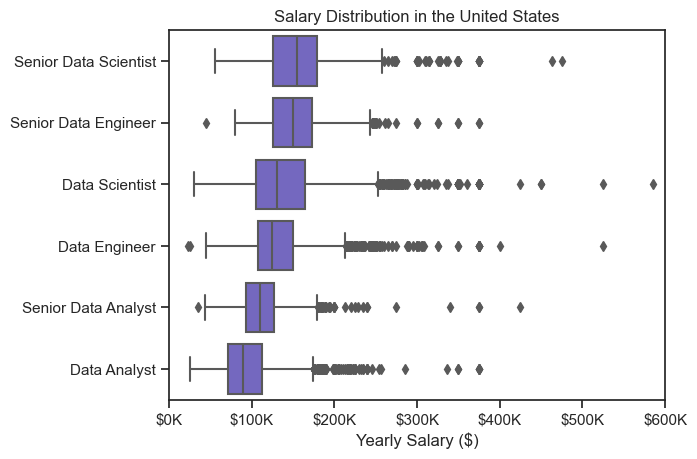

In [35]:
sns.boxplot(
    data=df_top_6, 
    x='salary_year_avg', 
    y='job_title_short',
    order=job_order,
    color='slateblue',
)

sns.set_theme(style='ticks')
plt.title('Salary Distribution in the United States')
plt.ylabel('')
plt.xlabel('Yearly Salary ($)')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda  x, pos: f'${int(x/1000)}K'
    )
)
plt.show()

In [36]:
# Only et the US Data Analyst job postings
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

In [37]:
# Explode Skills
df_US_DA = df_US_DA.explode('job_skills')

In [38]:
# Get top 10 skills ordered by count of skills
df_top_skills_count = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False).head(10).sort_values(by='median_salary', ascending=False)

# Get top 10 skills based on median yearly salary
df_top_pay = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='median_salary', ascending=False).head(10)

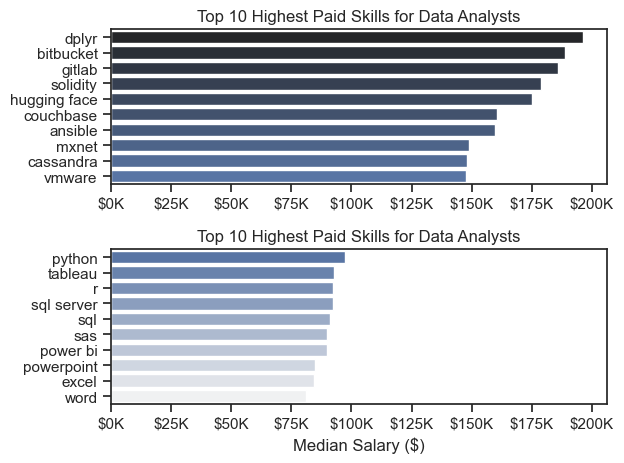

In [40]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')

sns.barplot(
    data=df_top_pay, 
    x='median_salary', 
    y=df_top_pay.index, 
    ax=ax[0],
    palette='dark:b'
)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

sns.barplot(
    data=df_top_skills_count, 
    x='median_salary', 
    y=df_top_skills_count.index, 
    ax=ax[1],
    palette='light:b_r'
)
ax[1].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

fig.tight_layout()
plt.show()